# Data Leakage Check — Train/Val Similarity Analysis

DeepGlobe tiles are cut from larger satellite images. Adjacent tiles may share roads, buildings, and geographic context. If our random train/val split places adjacent tiles in different sets, the model effectively sees part of the validation data during training — inflating metrics.

### Strategy
Instead of comparing all 5292x934 pairs, we focus on the **highest IoU samples** in both sets — if leakage exists, it would inflate these scores the most.

### Methods compared
1. **CLIP embeddings** — semantic similarity (understands scene content)
2. **ResNet encoder features** — visual similarity from our trained model

### Caching
Every expensive step (IoU computation, embedding extraction, similarity matrices) is cached to `data/interim/leakage_cache/`. If a cell fails downstream, re-running skips the expensive parts.

---
## 1. Setup

In [4]:
import subprocess, sys, os

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/minaessam2015/road-segmentation.git"

if IN_COLAB:
    REPO_DIR = "/content/road-segmentation"
    if not os.path.exists(REPO_DIR):
        subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
    else:
        subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", REPO_DIR], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "open-clip-torch"], check=True)
    PROJECT_ROOT = __import__('pathlib').Path(REPO_DIR).resolve()
else:
    PROJECT_ROOT = __import__('pathlib').Path.cwd().resolve()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from pathlib import Path
from tqdm import tqdm
from PIL import Image

plt.style.use("ggplot")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Cache directory ---
CACHE_DIR = Path("data/interim/leakage_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device: {device}")
print(f"Cache: {CACHE_DIR}")

Device: cpu
Cache: data/interim/leakage_cache


In [2]:
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_DIR = Path("/content/drive/MyDrive/road_segmentation")
    DRIVE_DIR.mkdir(parents=True, exist_ok=True)
    CHECKPOINT_DIR = str(DRIVE_DIR / "checkpoints")
    LOG_DIR = str(DRIVE_DIR / "logs")
    print(f"Checkpoints will be saved to: {CHECKPOINT_DIR}")
else:
    CHECKPOINT_DIR = "checkpoints"
    LOG_DIR = "logs"
    print(f"Checkpoints: {CHECKPOINT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoints will be saved to: /content/drive/MyDrive/road_segmentation/checkpoints


In [3]:
from road_segmentation.paths import DEEPGLOBE_DATASET_DIR

train_dir = DEEPGLOBE_DATASET_DIR / "train"
if not (train_dir.exists() and any(train_dir.glob("*_sat.*"))):
    print("Downloading dataset...")
    from road_segmentation.data.download import download_dataset
    download_dataset()

sat_count = len(list(train_dir.glob("*_sat.*")))
print(f"Training: {sat_count} image-mask pairs")

Training: 6226 image-mask pairs


---
## 2. Load Train/Val Split and Select Top-IoU Samples

In [14]:
from road_segmentation.paths import DEEPGLOBE_DATASET_DIR
from road_segmentation.data.eda import discover_image_mask_pairs
from road_segmentation.data.split import split_pairs

pairs = discover_image_mask_pairs(DEEPGLOBE_DATASET_DIR)
train_pairs, val_pairs = split_pairs(pairs, val_ratio=0.15, seed=42)

print(f"Train: {len(train_pairs)}, Val: {len(val_pairs)}")

# ====== SET YOUR CHECKPOINT (optional — for IoU-based selection) ======
CHECKPOINT = "/content/drive/MyDrive/road_segmentation/checkpoints/UnetPlusPlus_efficientnet-b4_20260406_231115/best.pth"  # Set to best.pth path, or leave empty for random selection

TOP_K = 500  # Number of top samples from each set to compare

Train: 5292, Val: 934


In [15]:
TOP_K = 500

In [16]:
import pickle

selection_cache = CACHE_DIR / "top_k_selection.pkl"

if selection_cache.exists():
    print(f"Loading cached selection from {selection_cache}")
    with open(selection_cache, "rb") as f:
        cached = pickle.load(f)
    train_top_idx = cached["train_top_idx"]
    val_top_idx = cached["val_top_idx"]

elif CHECKPOINT:
    print("Computing IoU for all samples (this takes a few minutes)...")
    from road_segmentation.models.factory import create_model
    from road_segmentation.data.transforms import get_val_transform
    from road_segmentation.data.dataset import RoadSegmentationDataset
    from torch.utils.data import DataLoader

    state = torch.load(CHECKPOINT, map_location=device, weights_only=False)
    cfg = state.get("config", {})
    model_cfg = cfg.get("model", {})
    data_cfg = cfg.get("data", {})
    norm_cfg = cfg.get("normalization", {})
    image_size = data_cfg.get("image_size", 1024)
    mean = norm_cfg.get("mean", [0.485, 0.456, 0.406])
    std = norm_cfg.get("std", [0.229, 0.224, 0.225])

    seg_model = create_model(
        arch=model_cfg.get("arch", "Unet"),
        encoder_name=model_cfg.get("encoder_name", "resnet34"),
        encoder_weights=None,
    )
    seg_model.load_state_dict(state["model_state_dict"])
    seg_model = seg_model.to(device).eval()

    val_transform = get_val_transform(image_size, mean, std)

    def compute_ious(pairs_list, model, transform):
        ds = RoadSegmentationDataset(pairs_list, transform=transform)
        loader = DataLoader(ds, batch_size=64, shuffle=False, num_workers=2)
        ious = []
        with torch.no_grad():
            for batch in tqdm(loader, desc="Computing IoU"):
                imgs = batch["image"].to(device)
                masks = batch["mask"]
                probs = torch.sigmoid(model(imgs)).cpu()
                for k in range(len(probs)):
                    pred = (probs[k, 0] >= 0.5).numpy()
                    gt = (masks[k, 0].numpy() > 0)
                    tp = (pred & gt).sum()
                    union = (pred | gt).sum()
                    ious.append(tp / max(union, 1))
        return np.array(ious)

    train_ious = compute_ious(train_pairs, seg_model, val_transform)
    val_ious = compute_ious(val_pairs, seg_model, val_transform)

    train_top_idx = np.argsort(train_ious)[-TOP_K:]
    val_top_idx = np.argsort(val_ious)[-TOP_K:]

    del seg_model
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    # Cache
    with open(selection_cache, "wb") as f:
        pickle.dump({"train_top_idx": train_top_idx, "val_top_idx": val_top_idx,
                     "train_ious": train_ious, "val_ious": val_ious}, f)
    print(f"Cached to {selection_cache}")

else:
    print(f"No checkpoint — using random {TOP_K} samples from each set.")
    rng = np.random.RandomState(42)
    train_top_idx = rng.choice(len(train_pairs), TOP_K, replace=False)
    val_top_idx = rng.choice(len(val_pairs), TOP_K, replace=False)

    with open(selection_cache, "wb") as f:
        pickle.dump({"train_top_idx": train_top_idx, "val_top_idx": val_top_idx}, f)

train_selected = [train_pairs[i] for i in train_top_idx]
val_selected = [val_pairs[i] for i in val_top_idx]
print(f"Comparing {TOP_K} train x {TOP_K} val = {TOP_K**2:,} pairs")

Computing IoU for all samples (this takes a few minutes)...
Cached to data/interim/leakage_cache/top_k_selection.pkl
Comparing 500 train x 500 val = 250,000 pairs


---
## 3. Method 1 — ResNet Feature Similarity

In [19]:
import torchvision.models as models
import torchvision.transforms as T

resnet_cache = CACHE_DIR / "resnet_embeddings.npz"

if resnet_cache.exists():
    print(f"Loading cached ResNet embeddings from {resnet_cache}")
    data = np.load(resnet_cache)
    train_resnet_emb = torch.from_numpy(data["train"])
    val_resnet_emb = torch.from_numpy(data["val"])
else:
    resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    resnet.fc = torch.nn.Identity()
    resnet = resnet.to(device).eval()

    resnet_transform = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    def extract_resnet_embeddings(pairs_list, model, transform):
        embeddings = []
        with torch.no_grad():
            for pair in tqdm(pairs_list, desc="ResNet embeddings"):
                img = Image.open(pair.image_path).convert("RGB")
                tensor = transform(img).unsqueeze(0).to(device)
                feat = model(tensor)
                feat = F.normalize(feat, dim=1)
                embeddings.append(feat.cpu())
        return torch.cat(embeddings, dim=0)

    print("Extracting ResNet embeddings...")
    train_resnet_emb = extract_resnet_embeddings(train_selected, resnet, resnet_transform)
    val_resnet_emb = extract_resnet_embeddings(val_selected, resnet, resnet_transform)

    # Cache
    np.savez(resnet_cache, train=train_resnet_emb.numpy(), val=val_resnet_emb.numpy())
    print(f"Cached to {resnet_cache}")

    del resnet
    if torch.cuda.is_available(): torch.cuda.empty_cache()

# Compute similarity matrix
resnet_sim = torch.mm(val_resnet_emb, train_resnet_emb.T).numpy()
print(f"ResNet sim matrix: {resnet_sim.shape} | max={resnet_sim.max():.4f} | mean={resnet_sim.mean():.4f}")

Extracting ResNet embeddings...


ResNet embeddings: 100%|██████████| 500/500 [00:04<00:00, 112.53it/s]

Cached to data/interim/leakage_cache/resnet_embeddings.npz
ResNet sim matrix: (500, 500) | max=0.9834 | mean=0.4519


---
## 4. Method 2 — CLIP Embedding Similarity

In [20]:
clip_cache = CACHE_DIR / "clip_embeddings.npz"

try:
    import open_clip
    CLIP_AVAILABLE = True
except ImportError:
    CLIP_AVAILABLE = False
    print("open-clip-torch not installed. Skipping CLIP.")

if CLIP_AVAILABLE:
    if clip_cache.exists():
        print(f"Loading cached CLIP embeddings from {clip_cache}")
        data = np.load(clip_cache)
        train_clip_emb = torch.from_numpy(data["train"])
        val_clip_emb = torch.from_numpy(data["val"])
    else:
        clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
            "ViT-B-32", pretrained="openai"
        )
        clip_model = clip_model.to(device).eval()

        def extract_clip_embeddings(pairs_list, model, preprocess):
            embeddings = []
            with torch.no_grad():
                for pair in tqdm(pairs_list, desc="CLIP embeddings"):
                    img = Image.open(pair.image_path).convert("RGB")
                    tensor = preprocess(img).unsqueeze(0).to(device)
                    feat = model.encode_image(tensor)
                    feat = F.normalize(feat, dim=1)
                    embeddings.append(feat.cpu())
            return torch.cat(embeddings, dim=0).float()

        print("Extracting CLIP embeddings...")
        train_clip_emb = extract_clip_embeddings(train_selected, clip_model, clip_preprocess)
        val_clip_emb = extract_clip_embeddings(val_selected, clip_model, clip_preprocess)

        # Cache
        np.savez(clip_cache, train=train_clip_emb.numpy(), val=val_clip_emb.numpy())
        print(f"Cached to {clip_cache}")

        del clip_model
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    clip_sim = torch.mm(val_clip_emb, train_clip_emb.T).numpy()
    print(f"CLIP sim matrix: {clip_sim.shape} | max={clip_sim.max():.4f} | mean={clip_sim.mean():.4f}")

Extracting CLIP embeddings...


CLIP embeddings: 100%|██████████| 500/500 [00:05<00:00, 87.10it/s]

Cached to data/interim/leakage_cache/clip_embeddings.npz
CLIP sim matrix: (500, 500) | max=0.9934 | mean=0.8248


### Cache similarity matrices

In [21]:
# Save similarity matrices so downstream cells never need to recompute
sim_cache = CACHE_DIR / "similarity_matrices.npz"
save_dict = {"resnet_sim": resnet_sim}
if CLIP_AVAILABLE:
    save_dict["clip_sim"] = clip_sim
np.savez(sim_cache, **save_dict)
print(f"Similarity matrices cached to {sim_cache}")

# Also save sample IDs for reference
import pickle
ids_cache = CACHE_DIR / "selected_sample_ids.pkl"
with open(ids_cache, "wb") as f:
    pickle.dump({
        "train_ids": [p.sample_id for p in train_selected],
        "val_ids": [p.sample_id for p in val_selected],
        "train_paths": [str(p.image_path) for p in train_selected],
        "val_paths": [str(p.image_path) for p in val_selected],
    }, f)
print(f"Sample IDs cached to {ids_cache}")

print(f"\nAll cached files:")
for p in sorted(CACHE_DIR.glob("*")):
    print(f"  {p.name} ({p.stat().st_size / 1e6:.1f} MB)")

Similarity matrices cached to data/interim/leakage_cache/similarity_matrices.npz
Sample IDs cached to data/interim/leakage_cache/selected_sample_ids.pkl

All cached files:
  clip_embeddings.npz (2.0 MB)
  resnet_embeddings.npz (8.2 MB)
  selected_sample_ids.pkl (0.2 MB)
  similarity_matrices.npz (2.0 MB)
  top_k_selection.pkl (0.1 MB)


---
## 5. Analysis — Similarity Distributions

Everything below uses only the cached matrices — safe to re-run without recomputing embeddings.

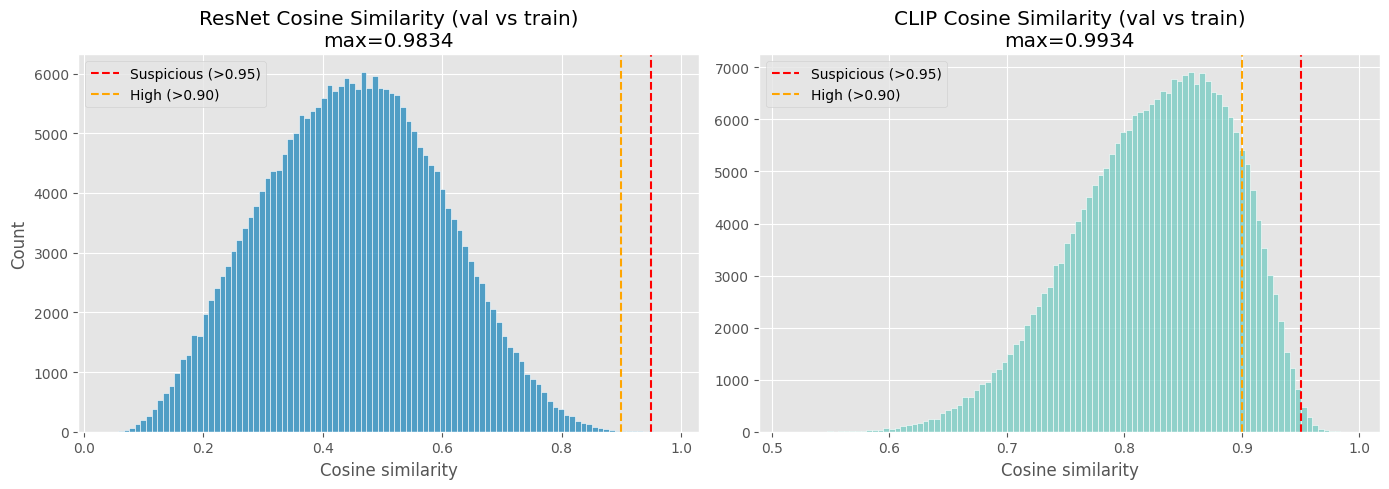

ResNet: 303 pairs above 0.85 | CLIP: 99393 pairs above 0.85
ResNet: 51 pairs above 0.9 | CLIP: 32175 pairs above 0.9
ResNet: 11 pairs above 0.95 | CLIP: 1037 pairs above 0.95


In [6]:
# Reload from cache if needed (e.g., after restart)
if 'resnet_sim' not in dir():
    data = np.load(CACHE_DIR / "similarity_matrices.npz")
    resnet_sim = data["resnet_sim"]
    CLIP_AVAILABLE = "clip_sim" in data.files
    if CLIP_AVAILABLE:
        clip_sim = data["clip_sim"]
    print("Loaded similarity matrices from cache.")

n_plots = 2 if CLIP_AVAILABLE else 1
fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5))
if n_plots == 1:
    axes = [axes]

resnet_flat = resnet_sim.ravel()
axes[0].hist(resnet_flat, bins=100, color="#2b8cbe", edgecolor="white", alpha=0.8)
axes[0].axvline(0.95, color="red", linestyle="--", label="Suspicious (>0.95)")
axes[0].axvline(0.90, color="orange", linestyle="--", label="High (>0.90)")
axes[0].set_title(f"ResNet Cosine Similarity (val vs train)\nmax={resnet_flat.max():.4f}")
axes[0].set_xlabel("Cosine similarity")
axes[0].set_ylabel("Count")
axes[0].legend()

if CLIP_AVAILABLE:
    clip_flat = clip_sim.ravel()
    axes[1].hist(clip_flat, bins=100, color="#7bccc4", edgecolor="white", alpha=0.8)
    axes[1].axvline(0.95, color="red", linestyle="--", label="Suspicious (>0.95)")
    axes[1].axvline(0.90, color="orange", linestyle="--", label="High (>0.90)")
    axes[1].set_title(f"CLIP Cosine Similarity (val vs train)\nmax={clip_flat.max():.4f}")
    axes[1].set_xlabel("Cosine similarity")
    axes[1].legend()

plt.tight_layout()
plt.show()

for thresh in [0.85, 0.90, 0.95]:
    resnet_count = (resnet_flat >= thresh).sum()
    msg = f"ResNet: {resnet_count} pairs above {thresh}"
    if CLIP_AVAILABLE:
        clip_count = (clip_flat >= thresh).sum()
        msg += f" | CLIP: {clip_count} pairs above {thresh}"
    print(msg)

---
## 6. Inspect Most Similar Pairs

In [8]:
# Reload sample paths from cache if needed
if 'train_selected' not in dir() or 'val_selected' not in dir():
    import pickle
    with open(CACHE_DIR / 'selected_sample_ids.pkl', 'rb') as f:
        ids_data = pickle.load(f)
    _train_paths_raw = ids_data['train_paths']
    _val_paths_raw = ids_data['val_paths']
else:
    _train_paths_raw = [str(p.image_path) for p in train_selected]
    _val_paths_raw = [str(p.image_path) for p in val_selected]


def normalize_path(p):
    """Convert absolute Colab/Drive paths to local paths.
    Extracts everything from 'data/raw/...' onwards and resolves
    relative to the current PROJECT_ROOT."""
    p = str(p)
    marker = 'data/raw/'
    idx = p.find(marker)
    if idx >= 0:
        relative = p[idx:]
        local = PROJECT_ROOT / relative
        if local.exists():
            return str(local)
    # Fallback: return as-is if it exists, otherwise try just the filename
    if Path(p).exists():
        return p
    from road_segmentation.paths import DEEPGLOBE_DATASET_DIR
    fallback = DEEPGLOBE_DATASET_DIR / 'train' / Path(p).name
    return str(fallback)


_train_paths = [normalize_path(p) for p in _train_paths_raw]
_val_paths = [normalize_path(p) for p in _val_paths_raw]

# Verify a sample path exists
print(f'Sample path: {_val_paths[0]}')
print(f'Exists: {Path(_val_paths[0]).exists()}')


def show_top_pairs(sim_matrix, val_paths, train_paths, method_name, n=10):
    flat_idx = np.argsort(sim_matrix.ravel())[-n:][::-1]
    val_idx = flat_idx // sim_matrix.shape[1]
    train_idx = flat_idx % sim_matrix.shape[1]

    fig, axes = plt.subplots(n, 2, figsize=(8, 3 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    for i in range(n):
        vi, ti = val_idx[i], train_idx[i]
        sim_score = sim_matrix[vi, ti]

        val_img = np.array(Image.open(val_paths[vi]).convert('RGB'))
        train_img = np.array(Image.open(train_paths[ti]).convert('RGB'))

        axes[i, 0].imshow(val_img)
        axes[i, 0].set_title(f'VAL: {Path(val_paths[vi]).stem[-15:]}\nsim={sim_score:.4f}', fontsize=9,
                                   color='red' if sim_score >= 0.95 else 'black')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(train_img)
        axes[i, 1].set_title(f'TRAIN: {Path(train_paths[ti]).stem[-15:]}', fontsize=9)
        axes[i, 1].axis('off')

        axes[i, 0].set_ylabel(f'sim={sim_score:.3f}', fontsize=12, fontweight='bold',
                                    color='red' if sim_score >= 0.95 else 'orange' if sim_score >= 0.90 else 'black')

    fig.suptitle(f'Top {n} Most Similar Val-Train Pairs ({method_name})',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


show_top_pairs(resnet_sim, _val_paths, _train_paths, 'ResNet', n=20)

if CLIP_AVAILABLE:
    show_top_pairs(clip_sim, _val_paths, _train_paths, 'CLIP', n=20)


---
## 7. Method Comparison — ResNet vs CLIP

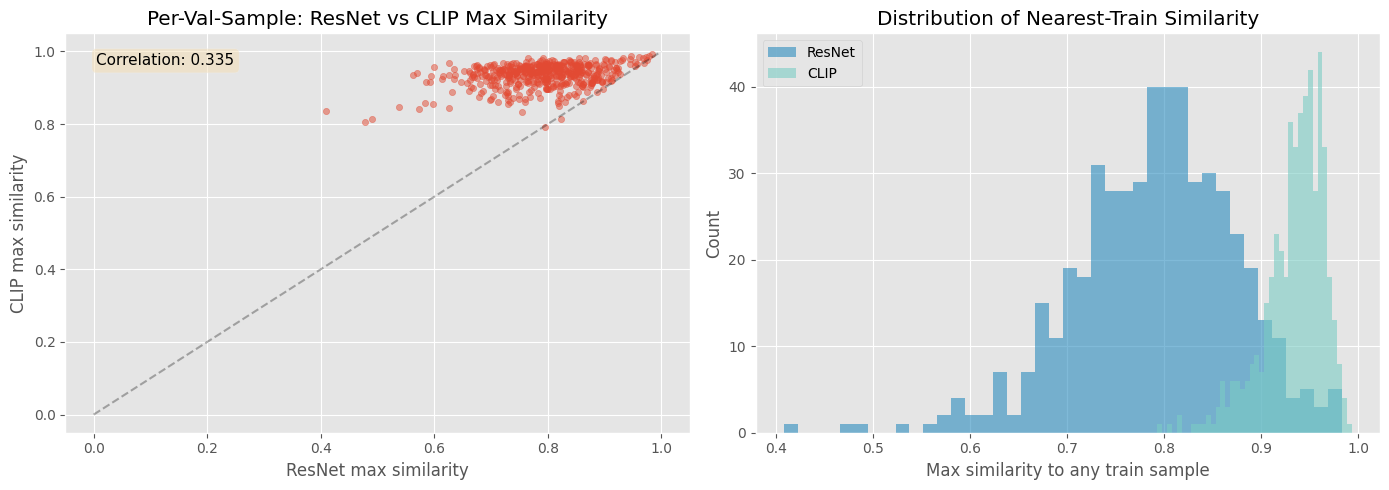

Correlation between methods: 0.335


In [7]:
if CLIP_AVAILABLE:
    resnet_max_per_val = resnet_sim.max(axis=1)
    clip_max_per_val = clip_sim.max(axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(resnet_max_per_val, clip_max_per_val, alpha=0.5, s=20)
    axes[0].set_xlabel("ResNet max similarity")
    axes[0].set_ylabel("CLIP max similarity")
    axes[0].set_title("Per-Val-Sample: ResNet vs CLIP Max Similarity")
    axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)

    corr = np.corrcoef(resnet_max_per_val, clip_max_per_val)[0, 1]
    axes[0].text(0.05, 0.95, f"Correlation: {corr:.3f}", transform=axes[0].transAxes,
                 fontsize=11, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    axes[1].hist(resnet_max_per_val, bins=40, alpha=0.6, color="#2b8cbe", label="ResNet")
    axes[1].hist(clip_max_per_val, bins=40, alpha=0.6, color="#7bccc4", label="CLIP")
    axes[1].set_xlabel("Max similarity to any train sample")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Distribution of Nearest-Train Similarity")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    print(f"Correlation between methods: {corr:.3f}")
else:
    print("CLIP not available — skipping comparison.")

---
## 8. Verdict

In [9]:
print("Leakage Assessment")
print("=" * 60)

best_sim = resnet_sim
method = "ResNet"
if CLIP_AVAILABLE and clip_sim.max() > resnet_sim.max():
    best_sim = clip_sim
    method = "CLIP"

max_sim = best_sim.max()
n_above_90 = (best_sim.ravel() >= 0.90).sum()
n_above_95 = (best_sim.ravel() >= 0.95).sum()
total_pairs = best_sim.size

print(f"Method used: {method}")
print(f"Max similarity found: {max_sim:.4f}")
print(f"Pairs above 0.90: {n_above_90}/{total_pairs} ({n_above_90/total_pairs*100:.2f}%)")
print(f"Pairs above 0.95: {n_above_95}/{total_pairs} ({n_above_95/total_pairs*100:.2f}%)")

print()
if max_sim >= 0.95:
    print("HIGH LEAKAGE RISK: Near-duplicate tiles found between train and val.")
    print("Validation metrics are likely inflated. Consider:")
    print("  1. Removing the flagged val samples and re-evaluating")
    print("  2. Reporting both inflated and cleaned metrics in the write-up")
elif max_sim >= 0.90:
    print("MODERATE LEAKAGE RISK: Some highly similar (possibly adjacent) tiles found.")
    print("Metrics may be slightly optimistic. Acknowledge in the write-up.")
elif max_sim >= 0.80:
    print("LOW LEAKAGE RISK: Some similar scenes but no near-duplicates.")
    print("This is expected for satellite imagery from similar regions.")
else:
    print("MINIMAL LEAKAGE RISK: Train and val samples appear visually distinct.")
    print("The random split is reasonably safe for this dataset.")

Leakage Assessment
Method used: CLIP
Max similarity found: 0.9934
Pairs above 0.90: 32175/250000 (12.87%)
Pairs above 0.95: 1037/250000 (0.41%)

HIGH LEAKAGE RISK: Near-duplicate tiles found between train and val.
Validation metrics are likely inflated. Consider:
  1. Removing the flagged val samples and re-evaluating
  2. Reporting both inflated and cleaned metrics in the write-up


---
## 9. Cleaned IoU — Impact of Removing Leaky Samples

We have per-sample IoU for all 934 validation samples (cached from inference).
By removing val samples that have high similarity to any training sample,
we can measure how much leakage inflates our metrics — **without any new inference**.

In [12]:
import pickle
import pandas as pd

# Load all cached data
with open(CACHE_DIR / 'top_k_selection.pkl', 'rb') as f:
    sel = pickle.load(f)

val_ious_all = sel['val_ious']        # IoU for all 934 val samples
val_top_idx = sel['val_top_idx']       # indices into val_pairs for the top-K

sim_data = np.load(CACHE_DIR / 'similarity_matrices.npz')
resnet_sim = sim_data['resnet_sim']
clip_sim = sim_data['clip_sim'] if 'clip_sim' in sim_data.files else None

print(f'Val IoU (all {len(val_ious_all)} samples): mean={val_ious_all.mean():.4f}, median={np.median(val_ious_all):.4f}')
print(f'Similarity matrices: ResNet {resnet_sim.shape}', end='')
if clip_sim is not None:
    print(f', CLIP {clip_sim.shape}')
else:
    print()

Val IoU (all 934 samples): mean=0.6940, median=0.7106
Similarity matrices: ResNet (500, 500), CLIP (500, 500)


In [13]:
def compute_cleaned_iou(val_ious_all, val_top_idx, sim_matrix, threshold):
    """Remove val samples with max similarity above threshold, recompute mean IoU."""
    max_sim_per_val = sim_matrix.max(axis=1)
    leaky_mask = max_sim_per_val >= threshold
    leaky_val_indices = set(val_top_idx[leaky_mask])
    
    clean_ious = [iou for i, iou in enumerate(val_ious_all) if i not in leaky_val_indices]
    
    return {
        'threshold': threshold,
        'n_removed': len(leaky_val_indices),
        'n_remaining': len(clean_ious),
        'original_mean_iou': float(val_ious_all.mean()),
        'cleaned_mean_iou': float(np.mean(clean_ious)) if clean_ious else 0,
        'iou_delta': float(np.mean(clean_ious) - val_ious_all.mean()) if clean_ious else 0,
        'removed_mean_iou': float(val_ious_all[list(leaky_val_indices)].mean()) if leaky_val_indices else 0,
    }

thresholds = [0.80, 0.85, 0.90, 0.92, 0.95, 0.97, 0.99]

results_resnet = [compute_cleaned_iou(val_ious_all, val_top_idx, resnet_sim, t) for t in thresholds]
results_clip = [compute_cleaned_iou(val_ious_all, val_top_idx, clip_sim, t) for t in thresholds] if clip_sim is not None else []

print('ResNet-based cleaning:')
print('=' * 80)
df_resnet = pd.DataFrame(results_resnet)
display(df_resnet.round(4))

if results_clip:
    print('\nCLIP-based cleaning:')
    print('=' * 80)
    df_clip = pd.DataFrame(results_clip)
    display(df_clip.round(4))

ResNet-based cleaning:


,threshold,n_removed,n_remaining,original_mean_iou,cleaned_mean_iou,iou_delta,removed_mean_iou
0,0.80,233,701,0.694,0.6617,-0.0323,0.7912
1,0.85,119,815,0.694,0.6781,-0.0160,0.8034
2,0.90,39,895,0.694,0.6880,-0.0061,0.8334
3,0.92,21,913,0.694,0.6903,-0.0038,0.8581
4,0.95,10,924,0.694,0.6920,-0.0021,0.8855
5,0.97,4,930,0.694,0.6933,-0.0007,0.8671
6,0.99,0,934,0.694,0.6940,0.0000,0.0000



CLIP-based cleaning:


,threshold,n_removed,n_remaining,original_mean_iou,cleaned_mean_iou,iou_delta,removed_mean_iou
0,0.80,499,435,0.694,0.5820,-0.1120,0.7917
1,0.85,491,443,0.694,0.5848,-0.1092,0.7926
2,0.90,437,497,0.694,0.6039,-0.0902,0.7966
3,0.92,370,564,0.694,0.6242,-0.0698,0.8004
4,0.95,177,757,0.694,0.6653,-0.0287,0.8167
5,0.97,38,896,0.694,0.6878,-0.0063,0.8419
6,0.99,1,933,0.694,0.6939,-0.0002,0.8640


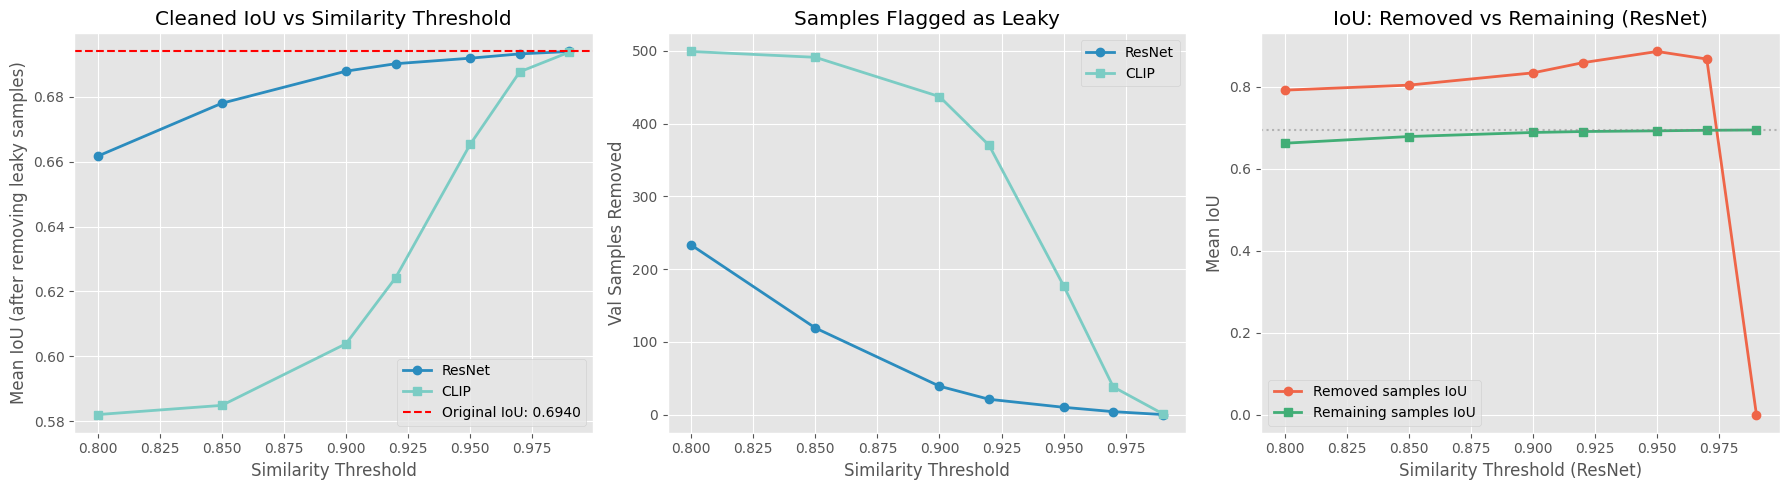

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Cleaned IoU vs threshold
resnet_thresholds = [r['threshold'] for r in results_resnet]
resnet_cleaned = [r['cleaned_mean_iou'] for r in results_resnet]
resnet_original = results_resnet[0]['original_mean_iou']

axes[0].plot(resnet_thresholds, resnet_cleaned, 'o-', label='ResNet', color='#2b8cbe', linewidth=2)
if results_clip:
    clip_cleaned = [r['cleaned_mean_iou'] for r in results_clip]
    axes[0].plot(resnet_thresholds, clip_cleaned, 's-', label='CLIP', color='#7bccc4', linewidth=2)
axes[0].axhline(resnet_original, color='red', linestyle='--', label=f'Original IoU: {resnet_original:.4f}')
axes[0].set_xlabel('Similarity Threshold')
axes[0].set_ylabel('Mean IoU (after removing leaky samples)')
axes[0].set_title('Cleaned IoU vs Similarity Threshold')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Samples removed
resnet_removed = [r['n_removed'] for r in results_resnet]
axes[1].plot(resnet_thresholds, resnet_removed, 'o-', label='ResNet', color='#2b8cbe', linewidth=2)
if results_clip:
    clip_removed = [r['n_removed'] for r in results_clip]
    axes[1].plot(resnet_thresholds, clip_removed, 's-', label='CLIP', color='#7bccc4', linewidth=2)
axes[1].set_xlabel('Similarity Threshold')
axes[1].set_ylabel('Val Samples Removed')
axes[1].set_title('Samples Flagged as Leaky')
axes[1].legend()
axes[1].grid(True)

# Plot 3: IoU of removed vs remaining
resnet_removed_iou = [r['removed_mean_iou'] for r in results_resnet]
axes[2].plot(resnet_thresholds, resnet_removed_iou, 'o-', label='Removed samples IoU', color='#ef6548', linewidth=2)
axes[2].plot(resnet_thresholds, resnet_cleaned, 's-', label='Remaining samples IoU', color='#41ae76', linewidth=2)
axes[2].axhline(resnet_original, color='gray', linestyle=':', alpha=0.5)
axes[2].set_xlabel('Similarity Threshold (ResNet)')
axes[2].set_ylabel('Mean IoU')
axes[2].set_title('IoU: Removed vs Remaining (ResNet)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [15]:
# Use ResNet at 0.90 threshold as the primary measure
use_results = results_resnet
best_result = next(r for r in use_results if r['threshold'] == 0.90)

print('Leakage Impact Summary')
print('=' * 60)
print(f'Method: ResNet (similarity threshold = 0.90)')
print(f'Total val samples:    {len(val_ious_all)}')
print(f'Samples removed:      {best_result["n_removed"]} ({best_result["n_removed"]/len(val_ious_all)*100:.1f}%)')
print(f'Samples remaining:    {best_result["n_remaining"]}')
print()
print(f'Original mean IoU:    {best_result["original_mean_iou"]:.4f}')
print(f'Cleaned mean IoU:     {best_result["cleaned_mean_iou"]:.4f}')
print(f'IoU inflation:        {abs(best_result["iou_delta"]):.4f} ({abs(best_result["iou_delta"]/best_result["original_mean_iou"])*100:.1f}%)')
print()
print(f'Removed samples IoU:  {best_result["removed_mean_iou"]:.4f}')
print()

if abs(best_result['iou_delta']) < 0.005:
    print('Conclusion: Leakage has NEGLIGIBLE impact on metrics (<0.5% IoU).')
    print('The validation IoU is reliable as reported.')
elif abs(best_result['iou_delta']) < 0.02:
    print('Conclusion: Leakage has MINOR impact on metrics.')
    print(f'Report both: original IoU={best_result["original_mean_iou"]:.4f}, cleaned IoU={best_result["cleaned_mean_iou"]:.4f}')
else:
    print('Conclusion: Leakage has SIGNIFICANT impact on metrics.')
    print(f'The cleaned IoU ({best_result["cleaned_mean_iou"]:.4f}) is more trustworthy.')
    print('Consider using a geographic split if tile coordinates become available.')

Leakage Impact Summary
Method: ResNet (similarity threshold = 0.90)
Total val samples:    934
Samples removed:      39 (4.2%)
Samples remaining:    895

Original mean IoU:    0.6940
Cleaned mean IoU:     0.6880
IoU inflation:        0.0061 (0.9%)

Removed samples IoU:  0.8334

Conclusion: Leakage has MINOR impact on metrics.
Report both: original IoU=0.6940, cleaned IoU=0.6880
